# Lab 7: Serial Communication and Robot Control (worked solutions)

Companion to `SerialCommunicationRobotControlTemplate.ipynb` and `pdfs/Serial_Communication_Robot_Control.pdf`.
Layout: **Task → Solution → How it works → Example / check**.

## How this notebook is safe to run anywhere
This lab drives the **real** arm. The solution notebook therefore has two switches at the top, both **off**:

| switch | default | meaning |
|---|---|---|
| `USE_REAL_ROBOT` | `False` | `False`: a **simulated robot** answers on the serial port. The real `serial_iface.py` code runs unchanged against it, so frame building and parsing are genuinely tested. `True`: open `/dev/serial0` (only on the Pi, only with the ROS controller **not** running). |
| `ALLOW_MOTION` | `False` | Only used with the real robot. `False`: commands that move the arm are printed but **not sent**. |

Recommended path: run everything once in simulation, read the explanations, then on the Pi set `USE_REAL_ROBOT = True`
(reading angles is harmless), and switch `ALLOW_MOTION = True` **only** after the checks and with a person at the stop.
The simulated robot is a teaching model: its speed law (1.5°/s per speed unit) and its behaviour after *stop* are
assumptions that you should compare with what the real arm does.

## Differences from the template's first cells (safety)
- The template (and the committed notebook) uses target `[90, 0, 0, 90, 0, 0]` at speed 100. That is a move of up to
  ~170° per joint at full speed. The solution starts from the **measured** pose, moves **joint 1 by +10°** at speed 20
  and validates the target first (`check_target`): the rule in `gameplan.md` §7 / §9. **Never send all zeros.**
- The serial port is `/dev/serial0` (the PDF and the controller launch file); the template says `/dev/ttyAMA0`, which is what
  `serial0` usually points to.

## Setup

In [1]:
%matplotlib widget
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import labpaths          # solutions/labpaths.py: puts the repo root on sys.path (for serial_iface)

USE_REAL_ROBOT = False    # True only on the Pi, with the ROS controller NOT running
ALLOW_MOTION = False      # real robot only: True lets motion commands be sent

**How it works:** the imports are the same as in the template. `labpaths` only makes `import serial_iface` work from this folder.
The two `bool` switches are read by the helper functions further down.

---
## Part 1: Direct serial communication
## Task 1: Inspect the codebase
The template asks you to read `serial_iface.py` and `mycobot_control.py`. Here is the guided tour of `serial_iface.py`
(class `MyCobotSerialInterface`):

| piece | what it does |
|---|---|
| `__init__(port, baud, timeout, ...)` | opens the port with `serial.Serial(port, baudrate, timeout, write_timeout)`; stores opcodes; creates a `threading.Lock` |
| `_build_packet(cmd, payload)` | static: `FE FE LEN CMD payload FA` with `LEN = 1 + len(payload) + 1` |
| `_write(packet)` | `ser.write(packet)` then `ser.flush()` (wait until all bytes left the buffer) |
| `_read_byte()` | `ser.read(1)`: one byte, or `None` if nothing arrived within `timeout` |
| `_scan_frame(want_cmd, want_len, deadline)` | **resynchronising parser**: skip bytes until `FE FE`, read `LEN`, read `LEN` bytes, check tail `FA`, command and length; otherwise keep scanning |
| `read_angles_deg()` | send `FE FE 02 20 FA`, scan for a `0x20` answer with 12 payload bytes, decode 6 × int16 / 100 |
| `send_angles_deg(angles, speed)` | encode 6 × (deg × 100) as int16 + speed byte into `FE FE 0F 22 … FA` |
| `stop_motion()`, `resume_motion()` | `FE FE 02 <opcode> FA` with opcodes 0x29 / 0x28 |
| `jog_joint(...)` | single-joint jog (opcode configurable), not used in this lab |
| `close()`, `flush_input()` | close the port, drop pending bytes |

The lock (`with self._lock:`) makes every call atomic when several threads use the port; that is why the template warns not to
run several serial cells at once.

The next cell shows how the numbers are packed, because that is the part worth understanding line by line.

In [2]:
# decode: two bytes -> signed 16 bit integer -> degrees   (the code in read_angles_deg)
hi, lo = 0xFF, 0x9C
raw = (hi << 8) | lo                # shift the high byte left by 8 bits and OR the low byte in: 0xFF9C = 65436
if raw & 0x8000:                    # is the sign bit (bit 15) set?
    raw -= 0x10000                  # two's complement: subtract 2^16 -> -100
print(f'raw = {raw}  ->  {raw / 100.0} deg')

# encode: degrees -> integer -> two bytes   (the code in send_angles_deg)
angle_deg = -1.5
v = int(round(angle_deg * 100.0))   # -150
if v < 0:
    v = (1 << 16) + v               # two's complement: 65536 - 150 = 65386 = 0xFF6A
print(f'{angle_deg} deg -> value {v} -> bytes {(v >> 8) & 0xFF:02X} {v & 0xFF:02X}')

# the same with the standard library
import struct
print(struct.pack('>h', -150).hex(' '), struct.unpack('>h', bytes([0xFF, 0x9C]))[0])

raw = -100  ->  -1.0 deg
-1.5 deg -> value 65386 -> bytes FF 6A
ff 6a -100


**How it works**
- A joint angle is stored as a **signed 16-bit integer** (`int16`) in units of 0.01°: range −327.68° … +327.67°,
  resolution 0.01°. Two bytes per joint, **big-endian** (high byte first).
- `hi << 8` shifts the bits 8 places to the left (multiply by 256); `|` (bitwise OR) merges the low byte in.
- **Two's complement:** negative numbers are stored as $2^{16} + v$. `raw & 0x8000` tests bit 15 (the sign bit);
  `raw - 0x10000` undoes the offset. `(v >> 8) & 0xFF` and `v & 0xFF` split a 16-bit number into its two bytes
  (`& 0xFF` keeps the low 8 bits).
- `struct.pack('>h', x)` / `struct.unpack('>h', b)` do the same in one call (`>` = big-endian, `h` = signed 16-bit).
- `0x9C` etc. are **hexadecimal** literals: `0x9C == 156`. `f'{b:02X}'` prints a byte as two upper-case hex digits.

---
## Task 2: Connection parameters

In [3]:
serial_port = '/dev/serial0'   # the serial device used by the robot (template: /dev/ttyAMA0; serial0 is a link to it)
baud_rate = 1_000_000          # 1 Mbaud, as an int (the template has the string '1_000_000', which the class converts with int())
timeout_s = 0.05               # read timeout in seconds

print(f'Port: {serial_port}, Baud: {baud_rate}, Timeout: {timeout_s} s')
print('int("1_000_000") =', int('1_000_000'))

Port: /dev/serial0, Baud: 1000000, Timeout: 0.05 s
int("1_000_000") = 1000000


**How it works**
- `/dev/serial0` is a **symbolic link** to the Pi's hardware UART (`ttyAMA0` or `ttyS0`, depending on the configuration).
  Using the link keeps the notebook independent of that detail.
- **Baud** = symbols per second. The port is 8N1 (8 data bits, no parity, 1 stop bit): 10 bits per byte on the wire, so
  1 000 000 baud ≈ 100 000 bytes/s. A 17-byte frame takes about 0.17 ms: the link is far faster than the robot moves.
- `1_000_000`: Python allows underscores as digit separators in number literals. The template passes the *string*
  `'1_000_000'`; that works only because the class does `int(baud)` and `int('1_000_000')` is valid.
- **Timeout:** how long `read` waits for a byte before giving up (`None`/empty). Short (0.05 s) so that a missing answer
  does not block the notebook; the higher-level `read_angles_deg(timeout_s=0.5)` uses it repeatedly until its own
  deadline.

---
## Communication frames
## Task 3: Protocol constants

In [4]:
HEAD = 0xFE
TAIL = 0xFA

CMD_READ_ANGLES = 0x20
CMD_SEND_ANGLES = 0x22
CMD_RESUME = 0x28
CMD_STOP = 0x29

print(f'Header: 0x{HEAD:02X}, Tail: 0x{TAIL:02X}')
print(f'Read angles: 0x{CMD_READ_ANGLES:02X}')
print(f'Send angles: 0x{CMD_SEND_ANGLES:02X}')
print(f'Stop: 0x{CMD_STOP:02X}, Resume: 0x{CMD_RESUME:02X}')

Header: 0xFE, Tail: 0xFA
Read angles: 0x20
Send angles: 0x22
Stop: 0x29, Resume: 0x28


**How it works**
- Frame: `FE FE LEN CMD [payload] FA`. **Header** `FE FE` marks the start (two bytes so a single stray `FE` is not
  mistaken for a start), **LEN** = number of bytes from CMD to the tail, **CMD** says what the frame means, **tail**
  `FA` marks the end and lets the receiver check that the frame is complete.
- Values in the source are written in hex: `0x20` = 32. Names in capitals are a convention for constants.
- `f'0x{HEAD:02X}'` prints the byte as `0xFE`.

---
## Task 4: Assemble a frame by hand

In [5]:
# Stop frame
stop_frame = bytes([0xFE, 0xFE, 0x02, 0x29, 0xFA])   # LEN = 1 (CMD) + 1 (FA) = 2
print('Stop frame:', stop_frame.hex(' '))

# Read-angles request frame
read_frame = bytes([0xFE, 0xFE, 0x02, 0x20, 0xFA])
print('Read frame:', read_frame.hex(' '))

Stop frame: fe fe 02 29 fa
Read frame: fe fe 02 20 fa


**How it works**
- `bytes([..])` turns a list of integers 0…255 into a `bytes` object (an immutable sequence of bytes, what
  `serial.write` needs). `.hex(' ')` prints it as hex with a space between bytes.
- **LEN rule:** `LEN = 1 (CMD) + len(payload) + 1 (tail)`. Stop and read-angles have no payload, so LEN = 2.
- These are exactly the bytes the class sends. Check against the class and the constants:

In [6]:
from serial_iface import MyCobotSerialInterface

def build_frame(cmd, payload=b''):
    """Own frame builder: FE FE LEN CMD payload FA with LEN = 1 + len(payload) + 1."""
    ln = 1 + len(payload) + 1
    return bytes([HEAD, HEAD, ln, cmd]) + bytes(payload) + bytes([TAIL])

print(build_frame(CMD_STOP) == stop_frame == MyCobotSerialInterface._build_packet(CMD_STOP))
print(build_frame(CMD_READ_ANGLES) == read_frame)
print(build_frame(0x22, bytes(range(12)) + b'\x14').hex(' '))     # a frame with a 13-byte payload: LEN = 15 = 0x0F

True
True
fe fe 0f 22 00 01 02 03 04 05 06 07 08 09 0a 0b 14 fa


- `MyCobotSerialInterface._build_packet` is a `staticmethod`: it can be called on the class without an object or a port.
- `bytes([a]) + bytes(payload) + bytes([b])`: `+` concatenates bytes objects. `bytes(range(12))` = 00 01 … 0B.
- Payload of 13 bytes gives `LEN = 15 = 0x0F`, the same LEN as a real send-angles frame (12 angle bytes + speed byte).

---
## Task 5: Frame-printing helper

In [7]:
def print_frame(label, frame_bytes):
    hex_str = ' '.join(f'{b:02X}' for b in frame_bytes)
    print(f'{label}: [{hex_str}] ({len(frame_bytes)} bytes)')

# Test with the stop frame
print_frame('Stop', stop_frame)
print_frame('Read', read_frame)

Stop: [FE FE 02 29 FA] (5 bytes)
Read: [FE FE 02 20 FA] (5 bytes)


**How it works:** `' '.join(f'{b:02X}' for b in frame_bytes)` is a **generator expression** inside `join`: iterating over a
`bytes` object gives integers, each formatted as two hex digits, joined by spaces. `len(frame_bytes)` counts the bytes.

---
## A simulated robot (so the notebook runs without the arm)
The class `SimulatedSerial` implements the **robot side** of the protocol, with the same methods the real `pyserial`
object has (`write`, `flush`, `read`, `reset_input_buffer`, `close`). It is a model, not the vendor firmware:
- read-angles request → answer `FE FE 0E 20 <12 bytes> FA`;
- send-angles → moves each joint towards the target at `1.5 °/s × speed` (assumption; speed 100 = 150 °/s);
- stop → freeze and ignore motion commands; resume → accept them again (the behaviour described in the template).
Reading it is a good way to understand the protocol from the other side.

In [8]:
class SimulatedSerial:
    """Stand-in for serial.Serial: behaves like a myCobot that speaks the FE FE LEN CMD ... FA protocol."""

    def __init__(self, start_deg, timeout=0.05):
        self.timeout = timeout
        self._to_host = bytearray()          # bytes the "robot" has sent and the host has not read yet
        self._from_host = bytearray()        # bytes received from the host, not yet parsed
        self.angles = np.array(start_deg, dtype=float)
        self.target = self.angles.copy()
        self.speed = 0
        self.stopped = False
        self._t = time.monotonic()
        self.tx_log = []                     # every frame the host wrote (for the printouts below)

    def _advance(self):
        """Physics: move the joints towards the target for the time passed since the last call."""
        now = time.monotonic(); dt = now - self._t; self._t = now
        if not self.stopped:
            step = 1.5 * self.speed * dt                       # degrees per joint (assumed)
            self.angles += np.clip(self.target - self.angles, -step, step)

    # --- the parts of the pyserial API that MyCobotSerialInterface uses
    def write(self, data):
        self.tx_log.append(bytes(data))
        self._from_host += data
        self._handle_frames()

    def flush(self): pass
    def reset_input_buffer(self): self._to_host.clear()
    def close(self): pass

    def read(self, n=1):
        deadline = time.monotonic() + self.timeout
        while len(self._to_host) < n and time.monotonic() < deadline:
            time.sleep(0.0005)
        chunk = bytes(self._to_host[:n]); del self._to_host[:n]
        return chunk

    # --- the robot side of the protocol
    def _handle_frames(self):
        while True:
            i = self._from_host.find(b'\xfe\xfe')
            if i < 0 or len(self._from_host) < i + 3:
                return
            ln = self._from_host[i + 2]
            end = i + 3 + ln
            if len(self._from_host) < end:
                return
            body = bytes(self._from_host[i + 3:end]); del self._from_host[:end]
            if body[-1] != 0xFA:
                continue                                        # invalid frame: ignore
            cmd, payload = body[0], body[1:-1]
            self._advance()
            if cmd == 0x20:                                     # read angles -> reply with 6 x int16 (deg*100)
                data = b''.join(int(round(a * 100)).to_bytes(2, 'big', signed=True) for a in self.angles)
                self._to_host += bytes([0xFE, 0xFE, 0x0E, 0x20]) + data + b'\xfa'
            elif cmd == 0x22 and not self.stopped:              # send angles: 6 x int16 + speed
                vals = [int.from_bytes(payload[2*k:2*k+2], 'big', signed=True) / 100.0 for k in range(6)]
                self.target = np.array(vals); self.speed = payload[12]
            elif cmd == 0x29:                                   # stop: freeze where we are
                self.stopped = True; self.target = self.angles.copy()
            elif cmd == 0x28:                                   # resume
                self.stopped = False

PARKED_DEG = [7.2, -99.31, -70.92, 81.38, 90.08, -74.26]        # pose read on the real robot in Lab 7 task 7
sim = SimulatedSerial(PARKED_DEG, timeout=timeout_s)

# a quick look at the robot side: ask it for its angles by hand
sim.reset_input_buffer()
sim.write(read_frame)
answer = sim.read(17)
print_frame('robot answer', answer)

robot answer: [FE FE 0E 20 02 D0 D9 35 E4 4C 1F CA 23 30 E2 FE FA] (17 bytes)


**How it works**
- **`bytearray`** is a mutable byte buffer: `+=` appends, `del buf[:n]` removes the first n bytes; `.find(b'\xfe\xfe')`
  searches for the header. This is how a receiver **frames** a byte stream: find a header, read LEN, wait until LEN more bytes are
  there, then process one whole frame.
- `int(round(a * 100)).to_bytes(2, 'big', signed=True)` and `int.from_bytes(..., 'big', signed=True)` are the built-in
  int16 conversions (same result as the manual two's-complement code above).
- `np.clip(target - angles, -step, step)`: each joint moves towards its target but at most `step` degrees per update: a
  constant-speed approach.
- The answer to the request has 17 bytes: `FE FE 0E 20` (4) + 12 payload + `FA` (1). `0E` = 14 = CMD + 12 + tail.

**Decoding the answer with our own code and comparing with the parked pose:**

In [9]:
def decode_angles_frame(frame):
    """FE FE 0E 20 <12 bytes> FA  ->  six angles in degrees."""
    assert frame[:2] == bytes([HEAD, HEAD]) and frame[-1] == TAIL, 'not a valid frame'
    assert frame[2] == len(frame) - 3, f'LEN mismatch: {frame[2]} vs {len(frame) - 3}'
    assert frame[3] == CMD_READ_ANGLES, 'not a read-angles answer'
    payload = frame[4:-1]
    return [int.from_bytes(payload[2*i:2*i+2], 'big', signed=True) / 100.0 for i in range(6)]

print(decode_angles_frame(answer))
print('matches the simulated pose:', np.allclose(decode_angles_frame(answer), PARKED_DEG))

[7.2, -99.31, -70.92, 81.38, 90.08, -74.26]
matches the simulated pose: True


- The asserts check the three properties of a valid frame: header/tail, `LEN` = number of following bytes, expected command.
  Any failing assert means corrupted or misinterpreted data: exactly the "validity checks" the PDF mentions.
- `payload[2*i:2*i+2]` is the *i*-th pair of bytes (slicing). The values equal the pose we started the simulation with.

---
## Reading robot state
## Task 6: Open the serial connection

In [10]:
import serial_iface
from serial_iface import MyCobotSerialInterface

def open_interface():
    kwargs = dict(port=serial_port, baud=baud_rate, timeout=timeout_s, num_joints=6,
                  stop_opcode=CMD_STOP, resume_opcode=CMD_RESUME)
    if USE_REAL_ROBOT:
        return MyCobotSerialInterface(**kwargs)             # opens /dev/serial0 for real
    real_Serial = serial_iface.serial.Serial                # simulation: let the constructor "open" the simulated port
    serial_iface.serial.Serial = lambda **kw: sim
    try:
        return MyCobotSerialInterface(**kwargs)
    finally:
        serial_iface.serial.Serial = real_Serial

ser = open_interface()
print('Serial port opened.', '(REAL robot)' if USE_REAL_ROBOT else '(simulated robot)')

Serial port opened. (simulated robot)


**How it works**
- The call is the template's: `MyCobotSerialInterface(port=..., baud=..., timeout=..., num_joints=6, stop_opcode=..., resume_opcode=...)`.
  Keyword arguments name each parameter; unspecified ones use the defaults of `__init__` (e.g. `move_opcode=0x34`).
- `dict(port=..., ...)` builds a dictionary; `**kwargs` **unpacks** it into keyword arguments.
- In simulation the constructor's call `serial.Serial(...)` is temporarily replaced by a function returning the simulated port
  (`lambda **kw: sim`: an anonymous function accepting any keyword arguments); the `try/finally` puts the original back
  afterwards even if something fails.
- **Real robot:** the port opens only if the ROS controller is not running. If it is, you get a "port busy" error
  (`fuser -v /dev/serial0` shows who has it).

---
## Task 7: Read the joint angles

In [11]:
measured_deg = ser.read_angles_deg(timeout_s=0.5)  # read the current joint angles from the robot

if measured_deg is not None:
    print('Measured joint angles (deg):', measured_deg)
else:
    print('No response from robot. Check connection and power.')

Measured joint angles (deg): [7.2, -99.31, -70.92, 81.38, 90.08, -74.26]


**How it works**
- The method sends `FE FE 02 20 FA`, then scans the incoming stream for a valid `0x20` frame with a 12-byte payload
  until `timeout_s` runs out (`None` if it never comes) and returns six angles in degrees.
- These are **measured** encoder values, not the last commanded ones.
- Always test for `None`: a missing answer (robot off, wrong port, bad baud rate) must not crash later code.
- Real robot, parked pose read in the lab: `[7.2, -99.31, -70.92, 81.38, 90.08, -74.26]`.

---
## Task 8: Compare with a reference

In [12]:
if measured_deg is not None:
    measured_arr = np.array(measured_deg)
    home_deg = np.zeros(6)
    diff_deg = measured_arr - home_deg  # difference between the measured and the all-zero configuration

    print('Measured (deg):', measured_arr)
    print('Home (deg):    ', home_deg)
    print('Difference (deg):', diff_deg)

Measured (deg): [  7.2  -99.31 -70.92  81.38  90.08 -74.26]
Home (deg):     [0. 0. 0. 0. 0. 0.]
Difference (deg): [  7.2  -99.31 -70.92  81.38  90.08 -74.26]


**How it works / interpretation**
- Arrays subtract element by element. The parked arm is nowhere near the all-zero pose (differences of up to 99°): the arm is folded
  in its rest position, while zero means "arm straight up".
- **Consequence for safety:** never use `home_deg = zeros` as a *target* from the parked pose: it would be a move of up to
  99° at once. The zeros are only a reference for the comparison.
- Even a robot exactly at zero would not read exactly `0.00`: encoder resolution (0.01°) and mechanical play.

---
## Sending position commands
## Task 9: A safe target

In [13]:
JOINT_LIMITS_DEG = np.array([[-168, 168], [-135, 135], [-150, 150], [-145, 145], [-165, 165], [-180, 180]])

def check_target(target_deg, max_step=15):
    """Print current -> target per joint and refuse limit violations or big moves (gameplan.md section 7)."""
    cur = np.array(ser.read_angles_deg(timeout_s=0.5))
    tgt = np.array(target_deg, dtype=float)
    assert tgt.shape == (6,), "need exactly 6 angles"
    assert np.all((tgt >= JOINT_LIMITS_DEG[:, 0]) & (tgt <= JOINT_LIMITS_DEG[:, 1])), f"outside joint limits: {tgt}"
    for j in range(6):
        print(f"J{j+1}: {cur[j]:8.2f} -> {tgt[j]:8.2f}   ({tgt[j]-cur[j]:+.2f} deg)")
    assert np.all(np.abs(tgt - cur) <= max_step), f"a joint moves more than {max_step} deg"
    return tgt.tolist()

# Small safe target: joint 1 by +10 degrees from the CURRENT (measured) pose, all other joints unchanged
target_deg = list(np.array(measured_deg) + np.array([10, 0, 0, 0, 0, 0]))
speed = 20        # slow: 1 (slowest) ... 100 (fastest)

print('Target (deg):', target_deg)
print('Speed:', speed)
target_deg = check_target(target_deg)

Target (deg): [17.2, -99.31, -70.92, 81.38, 90.08, -74.26]
Speed: 20
J1:     7.20 ->    17.20   (+10.00 deg)
J2:   -99.31 ->   -99.31   (+0.00 deg)
J3:   -70.92 ->   -70.92   (+0.00 deg)
J4:    81.38 ->    81.38   (+0.00 deg)
J5:    90.08 ->    90.08   (+0.00 deg)
J6:   -74.26 ->   -74.26   (+0.00 deg)


**How it works**
- **Relative to the measurement:** `np.array(measured_deg) + np.array([10, 0, ...])` adds 10° to joint 1 only. A target defined
  relative to where the arm *is* cannot cause a big jump.
- **`speed` 20 of 100:** the speed byte is a percentage of the maximum joint speed (1 = slowest, 100 = fastest).
- `check_target` is a **guard**: two `assert` statements refuse (raise `AssertionError`, nothing is sent) a target outside the
  joint limits or more than `max_step` degrees away from the current pose. It prints the per-joint plan so a human can read
  what will happen. The limits are the myCobot 280 data-sheet values (also in `gameplan.md`).
- `for j in range(6)` with the f-string format `{x:8.2f}` = width 8, 2 decimals, for aligned columns.
- `tgt.shape == (6,)`: the array must have exactly six entries; `send_angles_deg` also raises `ValueError` otherwise.

---
## Task 10: Send the position command

In [14]:
def send_position(target, speed):
    """Send a position command, unless it is the real robot and ALLOW_MOTION is off."""
    if USE_REAL_ROBOT and not ALLOW_MOTION:
        print('BLOCKED: ALLOW_MOTION is False; would send', np.round(target, 2), 'at speed', speed)
        return False
    ser.send_angles_deg(target, speed)
    return True

sent = send_position(target_deg, speed)
if sent:
    print('Position command sent.')
    print_frame('bytes on the wire', sim.tx_log[-1]) if not USE_REAL_ROBOT else None

# Wait for the motion to complete
time.sleep(3.0)

Position command sent.
bytes on the wire: [FE FE 0F 22 06 B8 D9 35 E4 4C 1F CA 23 30 E2 FE 14 FA] (18 bytes)


**How it works**
- `ser.send_angles_deg(angles, speed)` builds `FE FE 0F 22 [6 × int16] [speed] FA` and writes it. The command has **no answer**: the
  robot just starts moving. That is why the next tasks read the state back.
- `time.sleep(3.0)`: wait for the motion. A 10° move at speed 20 takes well under a second; 3 s leaves margin. Better than a fixed
  wait is to poll `read_angles_deg()` until the angles stop changing.
- The `print_frame(...) if not USE_REAL_ROBOT else None` one-liner is a conditional expression used as a statement: in simulation
  it shows the bytes that went on the wire (the real port cannot be inspected).

**Decode the frame that was sent (byte by byte):**

In [15]:
if not USE_REAL_ROBOT:                 # the simulated port records what was written; the real port cannot be inspected
    frame = sim.tx_log[-1]
    print(frame.hex(' '))
    print('header  :', frame[:2].hex(' '), '  LEN =', frame[2], '(= number of bytes after LEN)  CMD =', hex(frame[3]))
    angles = [int.from_bytes(frame[4 + 2*i: 6 + 2*i], 'big', signed=True) / 100 for i in range(6)]
    print('angles  :', angles, ' <- what we asked for:', np.round(target_deg, 2))
    print('speed   :', frame[16], '  tail =', hex(frame[17]))
    print('total   :', len(frame), 'bytes = 4 header/len/cmd + 12 angle bytes + 1 speed + 1 tail')

fe fe 0f 22 06 b8 d9 35 e4 4c 1f ca 23 30 e2 fe 14 fa
header  : fe fe   LEN = 15 (= number of bytes after LEN)  CMD = 0x22
angles  : [17.2, -99.31, -70.92, 81.38, 90.08, -74.26]  <- what we asked for: [ 17.2  -99.31 -70.92  81.38  90.08 -74.26]
speed   : 20   tail = 0xfa
total   : 18 bytes = 4 header/len/cmd + 12 angle bytes + 1 speed + 1 tail


- Byte layout: `FE FE` (2) · `0F` LEN · `22` CMD · 12 bytes = six int16 · speed · `FA`. LEN = 15 = CMD + 12 + speed + tail.
  Total 18 bytes on the wire.

---
## Task 11: Validate commanded vs measured

In [16]:
measured_after = ser.read_angles_deg(timeout_s=0.5)

if measured_after is not None:
    measured_after_arr = np.array(measured_after)
    target_arr = np.array(target_deg)
    error_deg = measured_after_arr - target_arr        # measured minus commanded

    print('Commanded (deg):', target_arr)
    print('Measured (deg): ', measured_after_arr)
    print('Error (deg):    ', error_deg)
    print('Max |error| (deg):', np.max(np.abs(error_deg)))

Commanded (deg): [ 17.2  -99.31 -70.92  81.38  90.08 -74.26]
Measured (deg):  [ 17.2  -99.31 -70.92  81.38  90.08 -74.26]
Error (deg):     [0. 0. 0. 0. 0. 0.]
Max |error| (deg): 0.0


**How it works / interpretation**
- Error = measured − commanded (sign convention: positive = the joint is further than requested). `np.max(np.abs(e))` is the worst
  joint.
- In the simulation the error is 0.00° because the model is perfect. On the real arm you typically see errors of
  a few hundredths up to about 0.1–0.5° (encoder resolution 0.01°, servo dead band and gravity load). What matters is that it is
  **small compared with the commanded move** (10°) and does not depend on the speed setting.
- **A large error means:** the motion is not finished yet (wait longer), the command was clipped or rejected (limits,
  robot in *stopped* state), or the frame was misinterpreted.

---
## Task 12: Plot commanded vs measured

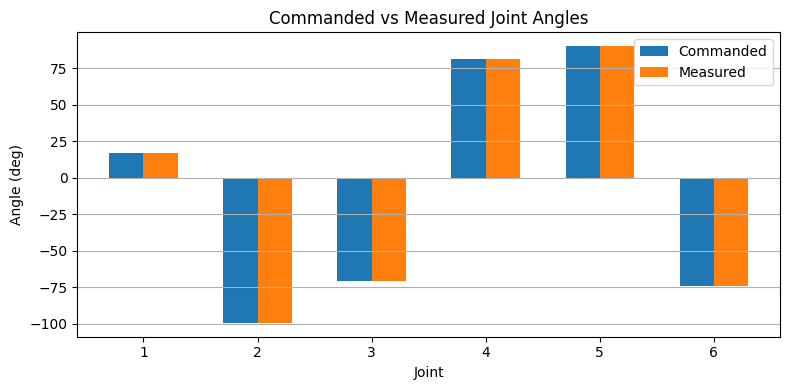

In [17]:
if measured_after is not None:
    joints = np.arange(1, 7)
    fig, ax = plt.subplots(figsize=(8, 4))
    width = 0.3
    ax.bar(joints - width/2, target_arr, width, label='Commanded')
    ax.bar(joints + width/2, measured_after_arr, width, label='Measured')
    ax.set_xlabel('Joint')
    ax.set_ylabel('Angle (deg)')
    ax.set_title('Commanded vs Measured Joint Angles')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()

**How it works**
- Grouped bar chart: `ax.bar(x, heights, width)`; shifting the two series by ±`width/2` puts the bars side by side.
- The bars look identical: the error (< 0.5°) is invisible next to angles of tens of degrees. To *see* the error, plot the
  **difference**:

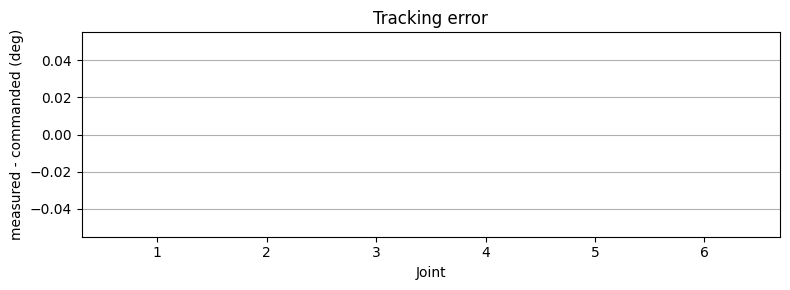

In [18]:
if measured_after is not None:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(joints, error_deg)
    ax.set_xlabel('Joint'); ax.set_ylabel('measured - commanded (deg)'); ax.set_title('Tracking error'); ax.grid(True, axis='y')
    plt.tight_layout()

---
## Stop and resume
## Task 13: Stop

In [19]:
ser.stop_motion()
print('Stop command sent.')

Stop command sent.


**How it works**
- `stop_motion()` writes `FE FE 02 29 FA`: no payload, the shortest possible frame, quick to send. Stopping is **allowed
  at any time, also with `ALLOW_MOTION = False`**: it can only make the robot safer.
- The wrapper lists the *stop* opcode passed to the constructor (`stop_opcode=CMD_STOP`), so the class does not have the value
  hard-coded.
- **Demonstration in the simulation** (the real arm should only do this when a person is watching): start a slow move,
  stop it halfway, and see that the arm stays where it was and ignores new commands.

In [20]:
if not USE_REAL_ROBOT:
    ser.resume_motion()                                     # make sure we start clean
    start = np.array(ser.read_angles_deg(timeout_s=0.5))
    ser.send_angles_deg(list(start + [10, 0, 0, 0, 0, 0]), 5)          # slow: speed 5 -> 7.5 deg/s in the model
    time.sleep(0.6)
    mid = np.array(ser.read_angles_deg(timeout_s=0.5))
    ser.stop_motion()
    time.sleep(0.6)
    after_stop = np.array(ser.read_angles_deg(timeout_s=0.5))
    ser.send_angles_deg(list(start + [0, 20, 0, 0, 0, 0]), 20)          # a command while stopped ...
    time.sleep(0.6)
    ignored = np.array(ser.read_angles_deg(timeout_s=0.5))
    print('J1 start / mid-motion / after stop / after a command sent while stopped:',
          round(start[0], 2), round(mid[0], 2), round(after_stop[0], 2), round(ignored[0], 2))
    print('J2 after the command sent while stopped (unchanged = ignored):', round(ignored[1], 2), '(was', round(start[1], 2), ')')

J1 start / mid-motion / after stop / after a command sent while stopped: 17.2 21.7 21.7 21.7
J2 after the command sent while stopped (unchanged = ignored): -99.31 (was -99.31 )


- The joint stops mid-way (about 4.5° instead of 10°) and stays there, and the later command is ignored until *resume*.
  This is the reason the template says a stop is "not optional": one frame, one write, and the arm halts.

---
## Task 14: Resume

In [21]:
ser.resume_motion()
print('Resume command sent.')

# Verify by reading angles
check = ser.read_angles_deg(timeout_s=0.5)
if check is not None:
    print('Robot responding. Angles (deg):', check)
else:
    print('No response after resume.')

Resume command sent.
Robot responding. Angles (deg): [21.7, -99.31, -70.92, 81.38, 90.08, -74.26]


**How it works**
- `resume_motion()` writes `FE FE 02 28 FA`. After it the robot accepts motion commands again. Reading angles afterwards is
  the **check that the link still works**: an answer proves the robot is alive and talking.
- A stop that is never followed by a resume would leave the robot ignoring commands: a common cause of "the robot doesn't
  move" in later labs.

In [22]:
if not USE_REAL_ROBOT:
    ser.send_angles_deg(list(start), 20)                    # go back to where we started (in the simulation)
    time.sleep(1.2)
    print('back at:', np.round(ser.read_angles_deg(timeout_s=0.5), 2))

back at: [ 17.2  -99.31 -70.92  81.38  90.08 -74.26]


---
## Task 15: Close the connection

In [23]:
ser.close()
print('Serial port closed. You can now launch the ROS 2 controller.')

Serial port closed. You can now launch the ROS 2 controller.


**How it works:** `close()` releases the device (under the lock, ignoring errors). **Why it is necessary:** only one process at a time
can own the port; while the notebook holds it, the controller node cannot open it (and vice versa). After a crash, restart
the kernel or run `fuser -v /dev/serial0` to find the process that still holds it.

**Reflection: why treat stop as part of the normal workflow?** Any command can turn out wrong: a typo in a target, a sign
error, an angle in radians where degrees were expected, an unexpected obstacle, a person reaching in. You cannot know in advance,
and the robot does not check whether a well-formed command is *sensible*. So the stop path is planned **before** the first move
(who is at the stop, which cell, which key), used freely in tests, and short (one frame). A stop that has never been tried is
not a safety mechanism. Treating it as "exceptional" means looking for it only when the arm is already heading for damage.

---
## Part 2: ROS 2 controller integration
**Not executed here** (it needs the running controller, which owns the serial port, and would move the arm). The cells are
complete and default to "do not move". Run them on the Pi after Part 1 is closed (`ser.close()`), with the controller launched:
```bash
source ~/venvs/mycobot/bin/activate
source ~/mycobot-project/ros2_ws/install/setup.bash
ros2 launch mycobot_control mycobot_control.launch.py
```
**Units change:** serial = degrees, ROS topics = radians (`/mycobot/joint_command` → controller does `math.degrees(x)`),
`/mycobot/joint_velocity` in rad/s, `/mycobot/joint_states` in rad, `/mycobot/ee_pose` = `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`.

---
## Task 16: Position mode vs velocity mode (and Task 17: inspect the topics)
- **Position mode** (`/mycobot/joint_command`): give a target configuration; the controller sends it to the robot, which
  drives there itself (one `send_angles` command at speed 50, per message). Use when the end state is known and the path in between does not matter.
- **Velocity mode** (`/mycobot/joint_velocity`): give a rate; the controller **integrates it to angle targets at 20 Hz** and streams
  them while the command stays active. Use for continuous or incremental motion (jogging, resolved-rate control, Lab 4).
  It needs extra care: deadband 0.01 rad/s, max ≈ 2.618 rad/s, all-zeros = stop, acceleration ramp 1 rad/s².
- Topic inspection (Task 17), in a terminal or with `!` in the notebook:
```bash
ros2 topic list
ros2 topic info /mycobot/joint_states        # sensor_msgs/msg/JointState, 1 publisher (the controller)
ros2 topic info /mycobot/joint_command       # std_msgs/msg/Float64MultiArray, 1 subscriber
ros2 topic info /mycobot/joint_velocity      # std_msgs/msg/Float64MultiArray, 1 subscriber
ros2 topic echo /mycobot/joint_states --once
```

---
## Task 18: A notebook node

In [ ]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray


class SerialLabNode(Node):
    def __init__(self):
        super().__init__('serial_lab_node')
        self.last_js = None
        self.js_sub = self.create_subscription(
            JointState, '/mycobot/joint_states', self._js_cb, 10,
        )

    def _js_cb(self, msg):
        self.last_js = msg

**How it works:** same pattern as Lab 2: a subclass of `Node` with a subscription whose callback stores the latest
message. `self.last_js = None` is the "no message yet" marker that later cells test for.

---
## Task 19: Initialize and spin once

In [ ]:
if not rclpy.ok():
    rclpy.init(args=None)

node = SerialLabNode()
rclpy.spin_once(node, timeout_sec=1.0)

if node.last_js is not None:
    print('Joint names:', node.last_js.name)
    print('Positions (rad):', list(node.last_js.position))
    print('Positions (deg):', [np.degrees(p) for p in node.last_js.position])
else:
    print('No joint state received. Is the controller running?')

**How it works:** `rclpy.init` once per process; `spin_once(node, timeout_sec=1.0)` waits up to a second for one
event (the state message is published at 5 Hz). Radians → degrees with `np.degrees` lets you compare with Part 1's readings: they
should agree with the serial values to within the encoder resolution.

---
## Task 20: Position-command publisher

In [ ]:
pos_pub = node.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)

**How it works:** `create_publisher(message_type, topic, queue_size)`. The topic expects **radians**.

---
## Task 21: Publish a safe position command (radians)

In [ ]:
JOINT_LIMITS_DEG = np.array([[-168, 168], [-135, 135], [-150, 150], [-145, 145], [-165, 165], [-180, 180]])

def check_target_rad(q_now, q_target, max_step_deg=15.0):
    q_now = np.asarray(q_now, dtype=float); q_target = np.asarray(q_target, dtype=float)
    lim = np.radians(JOINT_LIMITS_DEG)
    assert q_target.shape == (6,), "need exactly 6 joint values"
    assert np.all((q_target >= lim[:, 0]) & (q_target <= lim[:, 1])), f"outside joint limits: {np.degrees(q_target)}"
    step = np.degrees(q_target - q_now)
    for j in range(6):
        print(f"J{j+1}: {np.degrees(q_now[j]):8.2f} -> {np.degrees(q_target[j]):8.2f} deg  ({step[j]:+.2f})")
    assert np.all(np.abs(step) <= max_step_deg), f"a joint moves more than {max_step_deg} deg"

send_ros_motion = False    # a person sets this to True after checking the printed table

rclpy.spin_once(node, timeout_sec=1.0)
q_now = np.array(node.last_js.position, dtype=float)

q_cmd_rad = q_now + np.radians([10, 0, 0, 0, 0, 0])      # small, safe: joint 1 by +10 degrees from where the arm is
check_target_rad(q_now, q_cmd_rad)

msg = Float64MultiArray()
msg.data = q_cmd_rad.tolist()                             # message data must be a list of Python floats
if send_ros_motion:
    pos_pub.publish(msg)
    print(f'Published position command (rad): {q_cmd_rad}')
else:
    print('not published (send_ros_motion = False)')

# Wait and read back
time.sleep(3.0)
rclpy.spin_once(node, timeout_sec=0.5)
if node.last_js is not None:
    print('Measured (rad):', list(node.last_js.position))

**How it works**
- Same target as Task 9 (joint 1, +10° = 0.1745 rad), now in radians: `np.radians([10, 0, ...])`.
- `msg.data = q_cmd_rad.tolist()`: `Float64MultiArray.data` must be a Python list/sequence of floats, not a NumPy array (`.tolist()`
  converts).
- This is the higher-level twin of `send_angles_deg`: the controller converts radians → degrees and calls it (speed 50).
  **Do not run Part 1 and Part 2 against the same robot at the same time**: the port has one owner.

---
## Task 22: Velocity-command publisher

In [ ]:
vel_pub = node.create_publisher(Float64MultiArray, '/mycobot/joint_velocity', 10)

---
## Task 23: A safe velocity command
Safety rules from the template: small velocity (0.1 rad/s on one joint), short (1–2 s), be ready to stop, remember the
deadband (< 0.01 rad/s ignored) and that `[0]*6` stops. A velocity command keeps acting as long as it is published, so the stop is
in a `finally:` block.

In [ ]:
send_ros_velocity = False   # a person sets this to True after checking the predicted end position

# Small safe velocity: rotate joint 1 slowly
qdot_cmd = np.array([0.1, 0, 0, 0, 0, 0])      # rad/s: joint 1 at 0.1 rad/s = 5.7 deg/s
duration = 1.5                                  # seconds  ->  0.15 rad = 8.6 deg

rate_hz = 20.0
msg = Float64MultiArray()

q_end = q_now + qdot_cmd * duration
check_target_rad(q_now, q_end)                  # predicted end pose: inside the limits, a small move

if send_ros_velocity:
    start = time.time()
    try:
        while time.time() - start < duration:
            msg.data = qdot_cmd.tolist()        # convert the velocity command to the message data format
            vel_pub.publish(msg)
            rclpy.spin_once(node, timeout_sec=0.0)
            time.sleep(1.0 / rate_hz)
    finally:
        # Stop: send zero velocity
        msg.data = [0.0] * 6
        vel_pub.publish(msg)
        print('Velocity command completed. Stop sent.')
else:
    print('not published (send_ros_velocity = False)')

**How it works**
- 0.1 rad/s × 1.5 s = 0.15 rad ≈ 8.6°: comparable to the position test, so results can be compared.
- The `while` loop publishes at 20 Hz (`time.sleep(1/rate_hz)` between messages) for `duration` seconds.
  `spin_once(node, 0.0)` processes incoming state messages without waiting.
- `try … finally`: the code in `finally` runs **always**: normally, after an exception, or after a notebook interrupt.
  The all-zero message triggers the controller's immediate stop.
- The controller applies the acceleration ramp (1 rad/s²), so the joint needs ~0.1 s to reach 0.1 rad/s and the actual
  displacement is slightly smaller than 0.15 rad. That is a good example for Task 26.

---
## Commanded vs measured motion
## Task 24: Record the measured state over time

In [ ]:
send_ros_record = False    # a person sets this to True after checking the printed table

# Send a target: joint 1 by +8 degrees from the current pose
q_target_rad = q_now + np.radians([8, 0, 0, 0, 0, 0])
check_target_rad(q_now, q_target_rad)
msg = Float64MultiArray()
msg.data = q_target_rad.tolist()
if send_ros_record:
    pos_pub.publish(msg)

# Record measured states
timestamps = []
measured_positions = []
start = time.time()
record_duration = 4.0

while time.time() - start < record_duration:
    rclpy.spin_once(node, timeout_sec=0.05)
    if node.last_js is not None:
        timestamps.append(time.time() - start)
        measured_positions.append(list(node.last_js.position))
    time.sleep(0.1)

timestamps = np.array(timestamps)
measured_positions = np.array(measured_positions)
print(f'Recorded {len(timestamps)} samples over {record_duration} s')

**How it works**
- Two lists collect `(time, six joint values)`; converting them to arrays afterwards makes plotting easy (`measured_positions`
  has shape *samples × 6*).
- `spin_once(node, timeout_sec=0.05)` waits up to 50 ms for a state message, then `time.sleep(0.1)`: about 10 samples per
  second (the controller publishes at 5 Hz, so consecutive samples are sometimes identical).
- `time.time() - start` is the elapsed time in seconds.

---
## Task 25: Plot the motion

In [ ]:
if len(timestamps) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    for j in range(measured_positions.shape[1]):
        ax.plot(timestamps, np.degrees(measured_positions[:, j]), label=f'q{j+1}')
        ax.axhline(np.degrees(q_target_rad[j]), color=f'C{j}', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Angle (deg)')
    ax.set_title('Measured joint motion toward commanded target')
    ax.legend(fontsize=7)
    ax.grid(True)
    plt.tight_layout()

**How it works:** one solid line per joint (measured), one dashed horizontal line per joint in the same colour (commanded
target); `color=f'C{j}'` picks the *j*-th colour of Matplotlib's default cycle so line and target match. Joint 1 should
rise from the old to the new angle and level off at the dashed line; the other joints stay flat.

---
## Task 26: Why commanded and measured values differ
1. **Motion in progress:** the robot needs time; a sample taken during the move is between the start and the target. Look at
   the *end* of the recording to judge the final error.
2. **Sampling delay:** the state is published at 5 Hz (every 0.2 s) and read at discrete times; the plotted curve is a staircase
   of old values, up to a fifth of a second late.
3. **Controller limits:** speed cap (150°/s), acceleration ramp (1 rad/s²), `max_step_deg` (2° per tick when streaming), so
   the arm does not follow a step instantly.
4. **Mechanics and encoders:** backlash in the gears, servo dead band, gravity load and encoder resolution (0.01°) leave a
   final error of a small fraction of a degree even when the arm has "arrived".
5. **Estimated states:** with `publish_estimated_states = True` the controller may publish its *own* estimate right after a command
   (`_publish_joint_states_from_deg(...)` in `_pos_cb`); such a value shows the command, not a measurement. That is why the
   controller re-reads the angles from the robot afterwards.

---
## Safety and practical precautions
## Task 27: Pre-motion checklist

In [32]:
checklist = {
    'Workspace clear of obstacles and people': False,
    'Direction and size of the motion understood (printed table read)': False,
    'Stop mechanism known and within reach (which cell / key)': False,
    'Commands modest: small step, slow speed': False,
    'Serial port or controller confirmed active (only one of them!)': False,
}
for item, ok in checklist.items():
    print(f"[{'x' if ok else ' '}] {item}")
print('Safety checklist confirmed:', all(checklist.values()))

[ ] Workspace clear of obstacles and people
[ ] Direction and size of the motion understood (printed table read)
[ ] Stop mechanism known and within reach (which cell / key)
[ ] Commands modest: small step, slow speed
[ ] Serial port or controller confirmed active (only one of them!)
Safety checklist confirmed: False


**How it works:** a dictionary maps each item to `False`; **a person changes an entry to `True` after checking it in reality**. `all(...)`
is `True` only if every value is `True`. The point is the habit: the code cannot check the physical world, so the notebook
makes you say it.

---
## Task 28: Why real-robot operation needs more caution
- **Physical consequences:** a real arm can injure people, break itself, the tool, the workspace or the table. A simulation
  can be reset; a collision cannot be undone.
- **Irreversibility and speed:** the robot acts on the first well-formed command; there is no "are you sure", and the motion can
  start before you notice a mistake.
- **Model vs hardware gap:** simulation assumes perfect execution. The real arm has friction, backlash, gravity load, servo
  limits, sensor noise, latency, an uncalibrated tool and a slightly different geometry than the URDF (Labs 2, 5). Model
  assumptions such as "the joint reaches the target" do not always hold.
- **Unknown state:** the robot may be in a different pose than assumed (as with the parked pose that is far from zero) or in a
  stopped state that silently ignores commands.
- **Communication faults:** a dropped or misparsed frame, a wrong port or a second process on the port fails without
  the safety net that a simulator gives (exceptions, resets).
- Hence: validate targets, small steps first, read the state, keep the stop ready, and never run unattended.

---
## Task 29: Summary reflection
1. **What does the serial protocol contribute to reliable robot interaction?** A defined, byte-exact language: what a command
   means, how the numbers are encoded (int16 × 0.01°), where messages start and end, and how to read the state back. It turns a
   raw byte stream into checkable messages.
2. **Why does the frame structure matter?** The header `FE FE` lets a receiver find the start of a message and **resynchronise**
   after garbage or a partial frame (the parser just scans for the next header); `LEN` says how many bytes to read; the tail
   `FA` and the length check reveal truncated or corrupted frames; `CMD` selects the meaning. Without framing, a lost byte would
   shift every following value and the robot would act on wrong numbers.
3. **Why is comparing commanded vs measured motion essential?** A command is only a request. The measured state is the evidence of
   what happened: it shows whether the link works, whether the command was encoded and accepted correctly, how fast and how
   accurately the robot follows, and reveals problems such as a stopped state, a limit or a mechanical fault.
4. **Position vs velocity mode?** Position mode when the goal configuration is known and the path in between is unimportant
   (the robot's own controller reaches it, one command). Velocity mode when motion must be continuously adjusted or incremental
   (jogging, Cartesian control with the Jacobian): the robot moves as long as the command stays active, so it needs a limited
   magnitude, a supervisor and an immediate stop.

---
## Short questions from the PDF (preparation for the interview)
1. **Purpose of serial communication?** It is the gateway between the computer (Pi) and the robot controller: a byte stream over
   which commands are sent and measured state is read back. Without an open, correctly configured port nothing can be
   commanded or measured.
2. **Why a frame or packet structure?** To separate messages in a byte stream, identify their type, carry a payload of known
   length and detect errors (header, LEN, CMD, tail): reliable interpretation of commands and state, and resynchronisation after errors.
3. **Commanded vs measured values?** Commanded = target sent by the notebook; measured = what the encoders report after sensing.
   They differ while moving, through sampling, controller limits and mechanical effects.
4. **Position vs velocity mode?** Position: a target configuration, the robot drives there. Velocity: a rate, motion lasts
   as long as the request is active; needs care and a stop.
5. **Why validate before sending?** A well-formed command is not automatically safe or sensible: wrong units, a wrong joint,
   sign errors or values outside limits would be executed physically. Check target, limits, size of the step and free space first.
6. **Purpose of a safety stop?** To end or inhibit motion at once when something unexpected happens (wrong direction, unclear
   communication, a person in the workspace); it must be planned and tested before motion starts.
7. **Why compare commanded and measured motion?** It proves the communication chain works, exposes interpretation and unit
   errors, and shows delay, accuracy and limits of the real robot.
8. **Why more caution than in simulation?** See Task 28: physical, irreversible consequences, model-hardware gap, unknown or stopped
   state, communication faults.

---
## Summary
- Frame: `FE FE LEN CMD payload FA`, `LEN = 1 + len(payload) + 1`. Angles: int16, big-endian, degrees × 100. Speed 1–100.
- Commands: read `0x20` (answer 17 bytes), send `0x22` (18 bytes, no answer), stop `0x29`, resume `0x28`.
- Workflow: open → read → validate the target → small slow move → read back and compare → stop/resume → close.
- The serial port has **one owner**: the notebook or `mycobot_control`.
- Defaults here: simulation, motion off, targets relative to the measured pose, `check_target`, stop in `finally:`.